# QMUGS Nested Isosurface Plot
Render one QMUGS molecule with nested electron-density isosurfaces only.

In [22]:
import json
import sys
from pathlib import Path

import numpy as np
import pyvista as pv

sys.path.append("/export/home/mklockow/boa")
from boa.data.dataset import read_pyscf

# Config-aligned layout (see configs/data/datamodule/dataset/qm9_pyscf.yaml):
# _target_: boa.data.dataset.PyscfDataset
# path: ${paths.data_dir}/${data.dataset_name}/data
qmugs_root = Path("/export/scratch/mklockow/boa/data/qmugs_pyscf")
qmugs_data_dir = qmugs_root / "data"
split_file = qmugs_root / "datasplits.json"

with split_file.open() as f:
    splits = json.load(f)

mol_id = int(splits["test"][0])
atom_types, atom_coords, cell, density, _, _ = read_pyscf(qmugs_data_dir / str(mol_id))

print(f"Loaded QMUGS molecule {mol_id} from {qmugs_data_dir}")
print(f"density shape={tuple(density.shape)}, n_atoms={atom_coords.shape[0]}")

Loaded QMUGS molecule 7117199 from /export/scratch/mklockow/boa/data/qmugs_pyscf/data
density shape=(316, 256, 236), n_atoms=194


In [23]:
density_np = density.detach().cpu().numpy()
density_np = np.nan_to_num(density_np, nan=0.0, posinf=0.0, neginf=0.0)
density_np = np.clip(density_np, a_min=0.0, a_max=None)
if density_np.max() == 0.0:
    density_np = np.abs(density_np)

dims = np.array(density_np.shape, dtype=int)
cell_np = cell.detach().cpu().numpy()
cell_lengths = np.linalg.norm(cell_np, axis=1)
spacing = cell_lengths / (dims - 1)

rho_grid = pv.ImageData(
    dimensions=tuple(int(d) for d in dims),
    spacing=tuple(float(s) for s in spacing),
    origin=(0.0, 0.0, 0.0),
)
rho_grid["rho"] = density_np.ravel(order="F")

atom_types_np = atom_types.detach().cpu().numpy()
atom_coords_np = atom_coords.detach().cpu().numpy()

def _isosurface_threshold(values: np.ndarray, quantile: float) -> float:
    v = np.sort(values[values > 0])[::-1]
    if v.size == 0:
        return 0.0
    cumsum = np.cumsum(v)
    idx = np.searchsorted(cumsum, cumsum[-1] * quantile)
    return float(v[min(idx, v.size - 1)])

def _alpha_content_size(
    image_or_mask: np.ndarray,
    margin_frac: float = 0.05,
    min_size: int = 400,
    max_size: int = 10000,
    alpha_threshold: int = 8,
) -> tuple[int, int] | None:
    if image_or_mask.ndim == 2:
        alpha = image_or_mask > 0
    elif image_or_mask.ndim == 3 and image_or_mask.shape[-1] >= 4:
        alpha = image_or_mask[..., 3] > alpha_threshold
    elif image_or_mask.ndim == 3:
        alpha = np.any(image_or_mask[..., :3] < 250, axis=-1)
    else:
        return None

    if not np.any(alpha):
        return None

    ys = np.where(alpha.any(axis=1))[0]
    xs = np.where(alpha.any(axis=0))[0]

    content_width = int(xs[-1] - xs[0] + 1)
    content_height = int(ys[-1] - ys[0] + 1)
    margin_frac = float(np.clip(margin_frac, 0.0, 0.45))
    scale = 1.0 / (1.0 - 2.0 * margin_frac)
    width = int(np.ceil(content_width * scale))
    height = int(np.ceil(content_height * scale))

    width = int(np.clip(width, min_size, max_size))
    height = int(np.clip(height, min_size, max_size))
    return width, height

def get_atoms_only_mesh_dict(atom_types_arr, atom_coords_arr, atom_radius=0.22, resolution=36):
    atom_colors = {
        1: "#f2f2f2",
        6: "#606060",
        7: "#3b7ddd",
        8: "#d84a4a",
        9: "#97c93d",
        15: "#c98c3d",
        16: "#d5b541",
        0: "#7a7a7a",
    }

    mesh_elements = []
    for atomic_num, pos in zip(atom_types_arr, atom_coords_arr):
        atomic_num = int(atomic_num)
        color_id = atomic_num if atomic_num in atom_colors else 0
        sphere = pv.Sphere(
            center=pos,
            radius=atom_radius,
            phi_resolution=resolution,
            theta_resolution=resolution,
        )
        sphere["color_ids"] = np.ones(sphere.n_cells) * color_id
        mesh_elements.append(sphere)

    merged_mesh = pv.MultiBlock(mesh_elements).combine().extract_surface()
    return dict(
        mesh=merged_mesh,
        smooth_shading=True,
        diffuse=0.5,
        specular=0.45,
        ambient=0.45,
        clim=(0, max(atom_colors.keys())),
        cmap=[atom_colors[k] for k in sorted(atom_colors.keys())],
        show_scalar_bar=False,
    )

Nested isosurfaces for QMUGS 7117199: [(0.82, 0.0543915331363678, 398352), (0.6, 0.13346949219703674, 297488)]; window_size=(6996, 3773); alpha_debug=qmugs_alpha_debug_7117199.png


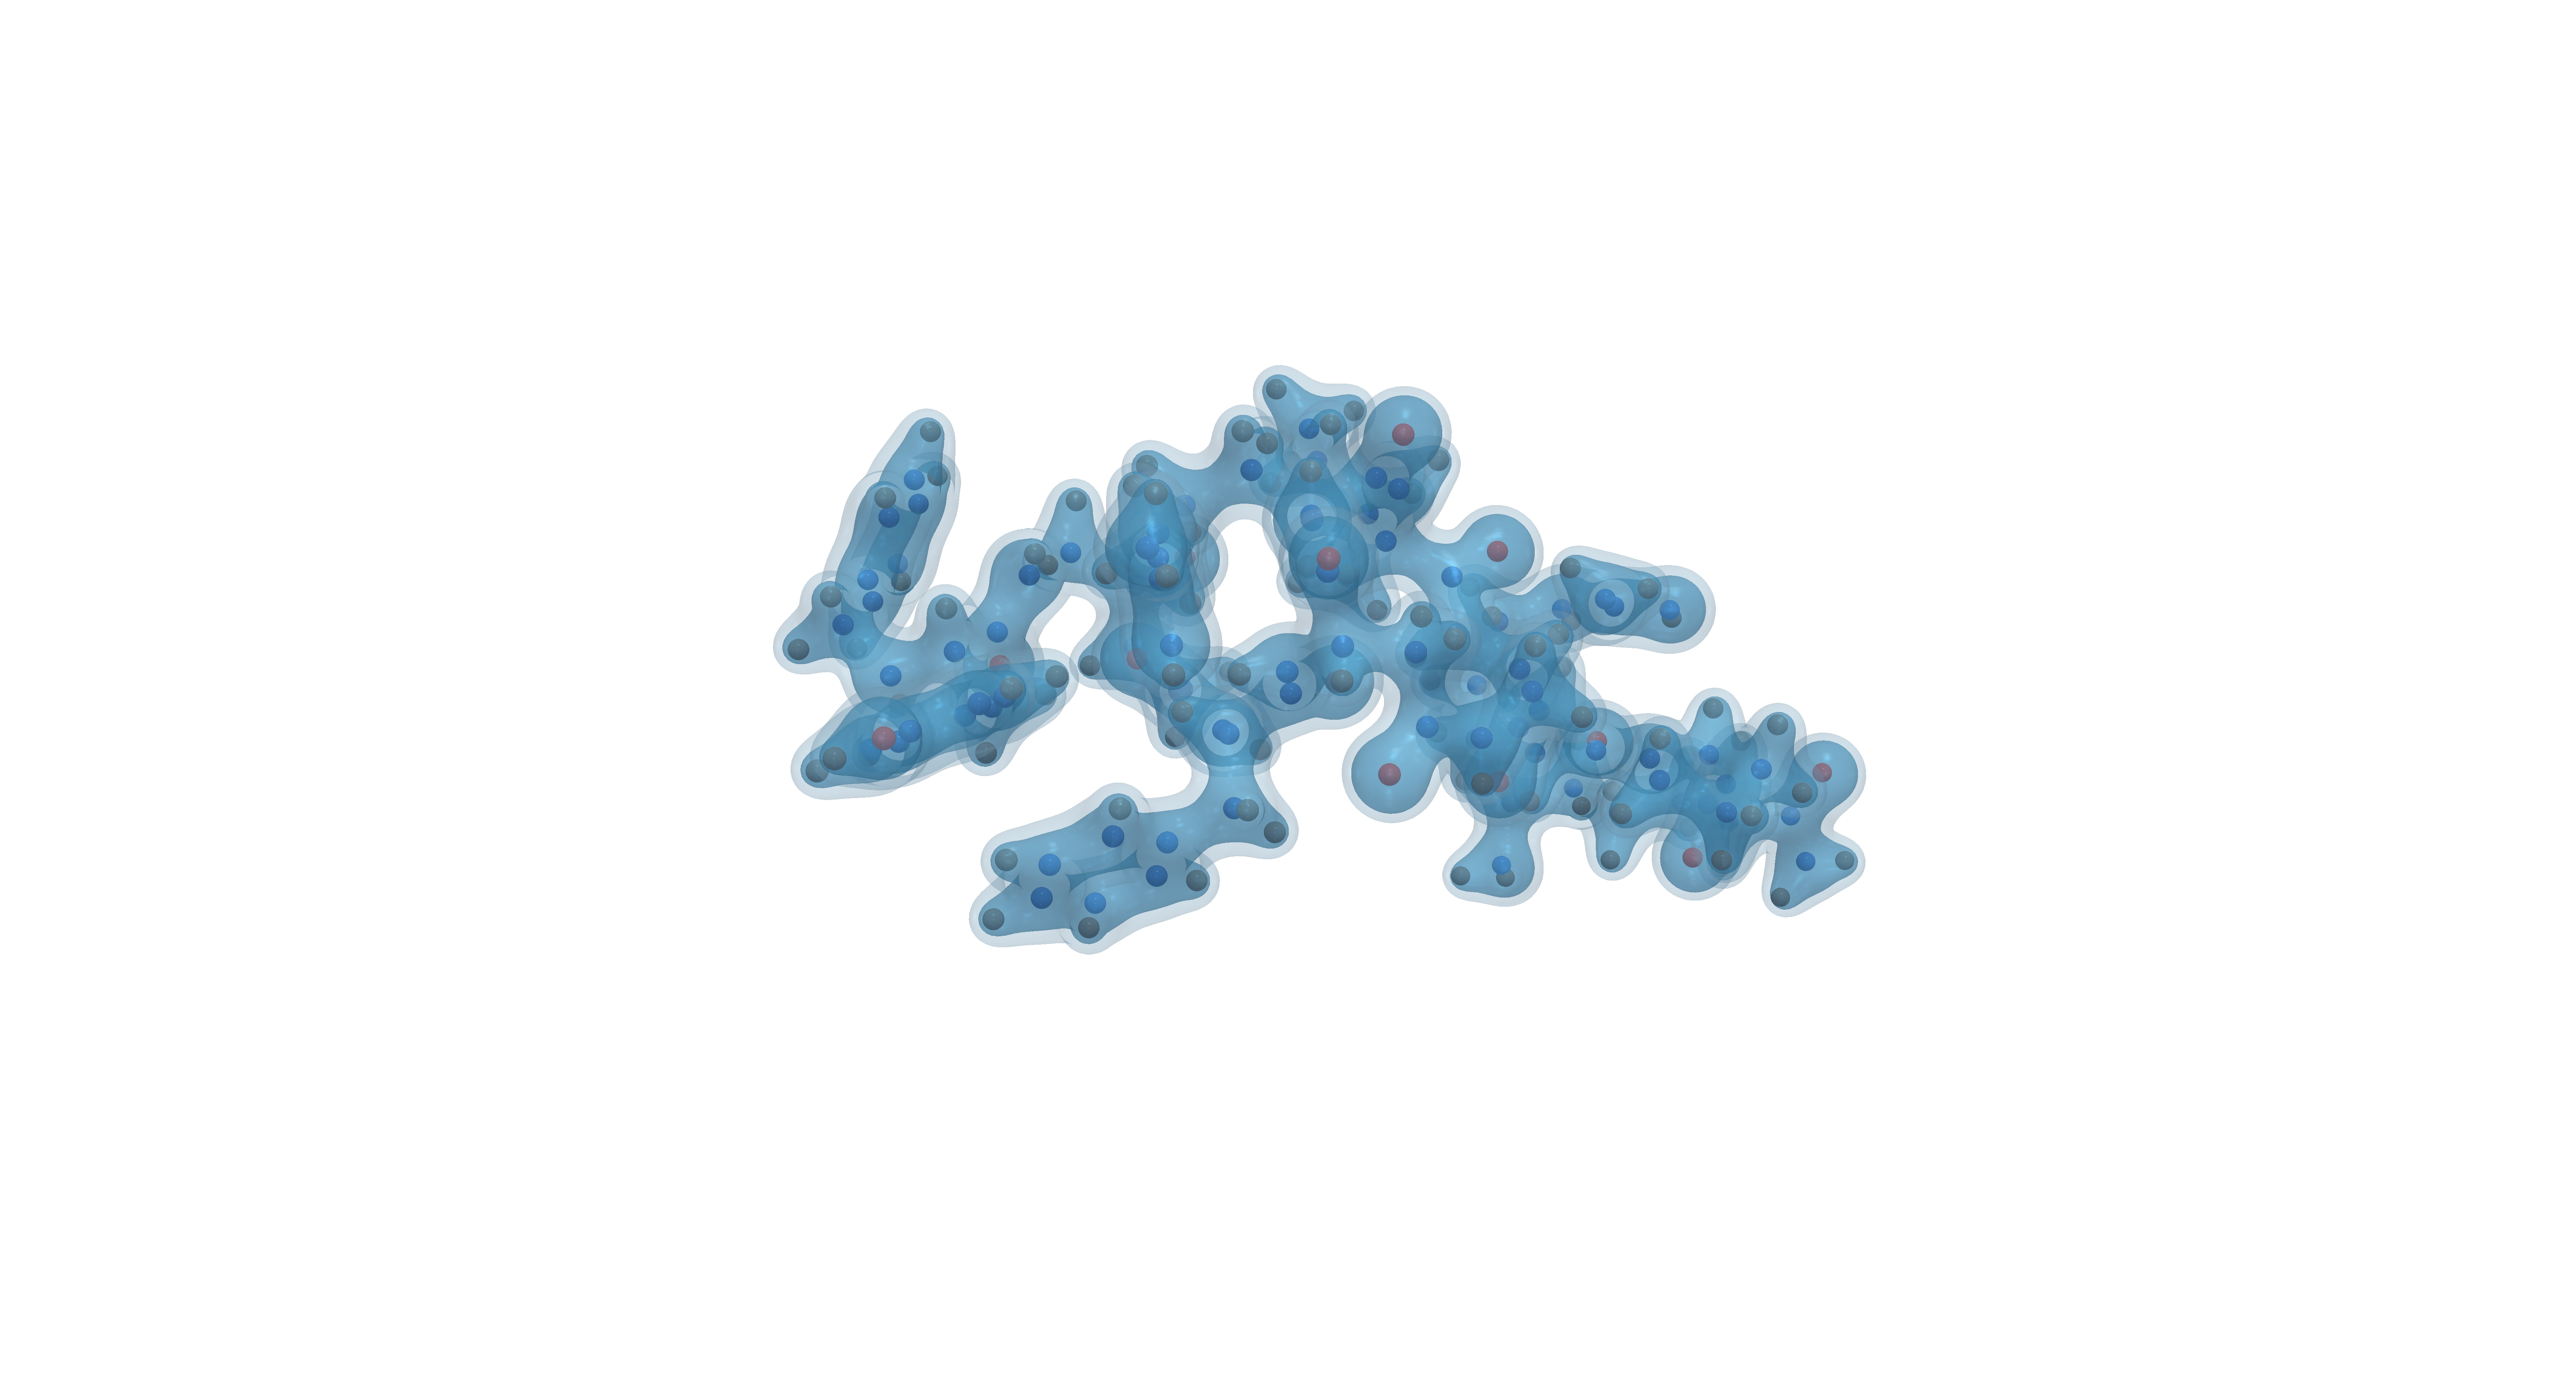

In [24]:
pv.set_jupyter_backend("static")
window_size = (8000, 8000)
nested_quantiles = [0.82, 0.60]
nested_colors = ["#8FC1E3", "#328CC1"]
nested_opacities = [0.20, 0.40]

plotter = pv.Plotter(notebook=True, window_size=window_size)
plotter.enable_anti_aliasing("msaa")
plotter.enable_depth_peeling(15)
plotter.add_mesh(**get_atoms_only_mesh_dict(atom_types_np, atom_coords_np))

plotted = []
for q, c, o in zip(nested_quantiles, nested_colors, nested_opacities):
    thr = _isosurface_threshold(density_np, quantile=q)
    if thr <= 0:
        continue
    surface = rho_grid.contour([thr], scalars="rho")
    if surface.n_cells == 0:
        continue

    plotter.add_mesh(
        surface,
        color=c,
        opacity=o,
        smooth_shading=True,
        specular=0.7,
        ambient=0.35,
        diffuse=0.8,
    )
    plotted.append((q, thr, surface.n_cells))

plotter.camera_position = "iso"
plotter.camera.zoom(1.2)

preview_img = plotter.screenshot(
    filename=None,
    transparent_background=True,
    return_img=True,
    window_size=window_size,
)

if preview_img.ndim == 3 and preview_img.shape[-1] >= 4:
    alpha_visible = preview_img[..., 3] > 8
    if not np.any(alpha_visible):
        alpha_visible = np.any(preview_img[..., :3] < 250, axis=-1)
elif preview_img.ndim == 3:
    alpha_visible = np.any(preview_img[..., :3] < 250, axis=-1)
else:
    alpha_visible = preview_img > 0

alpha_debug = np.where(alpha_visible, 0, 255).astype(np.uint8)
debug_path = f"qmugs_alpha_debug_{mol_id}.png"

import matplotlib.pyplot as plt
plt.imsave(debug_path, alpha_debug, cmap="gray", vmin=0, vmax=255)

auto_window_size = _alpha_content_size(alpha_visible, margin_frac=0.05)
if auto_window_size is not None:
    window_size = auto_window_size
    plotter.window_size = window_size

print(
    f"Nested isosurfaces for QMUGS {mol_id}: {plotted}; "
    f"window_size={window_size}; alpha_debug={debug_path}"
)
plotter.show()
_ = plotter.screenshot(
    f"qmugs_nested_isosurfaces_{mol_id}.png",
    transparent_background=True,
    window_size=window_size,
)